# Sod shock tube: exact solution vs finite-volume schemes

Companion to [Compressible flow](../fluids/compressible.md) and
[Finite volume](../fluids/cfd/finite-volume.md).

The Sod problem is the standard test for a compressible solver because its exact solution
is known and it contains all three wave families at once — a **left-moving rarefaction**,
a **contact discontinuity**, and a **right-moving shock**. A scheme's treatment of each is
visible separately.

What this notebook shows:

1. The exact solution, from an iterative Riemann solver.
2. Three finite-volume schemes against it, isolating two independent choices:
   **reconstruction order** and **Riemann solver fidelity**.
3. How each error converges under refinement — and why the contact behaves differently
   from the shock.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 3.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 9,
})

GAMMA = 1.4

# Sod's initial data: (density, velocity, pressure)
WL = (1.0,   0.0, 1.0)
WR = (0.125, 0.0, 0.1)
T_END, X0 = 0.20, 0.5

## 1. Exact solution

The two non-linear waves are coupled only through the star-region pressure $p_*$, which
satisfies

$$f_L(p_*) + f_R(p_*) + (u_R - u_L) = 0$$

with $f_K$ a shock relation when $p_* > p_K$ and a rarefaction relation otherwise.
One scalar root-find gives $p_*$; everything else follows algebraically.

In [2]:
def _f_and_df(p, rho_k, p_k, a_k, g=GAMMA):
    """Pressure function for one side, and its derivative."""
    if p > p_k:                                    # shock
        A = 2.0 / ((g + 1.0) * rho_k)
        B = (g - 1.0) / (g + 1.0) * p_k
        sq = np.sqrt(A / (B + p))
        return (p - p_k) * sq, sq * (1.0 - 0.5 * (p - p_k) / (B + p))
    # rarefaction
    pr = p / p_k
    return (2.0 * a_k / (g - 1.0) * (pr ** ((g - 1.0) / (2.0 * g)) - 1.0),
            pr ** (-(g + 1.0) / (2.0 * g)) / (rho_k * a_k))


def exact_star(WL, WR, g=GAMMA, tol=1e-12):
    """Newton iteration for star-region pressure and velocity."""
    rL, uL, pL = WL
    rR, uR, pR = WR
    aL, aR = np.sqrt(g * pL / rL), np.sqrt(g * pR / rR)

    p = max(tol, 0.5 * (pL + pR)
            - 0.125 * (uR - uL) * (rL + rR) * (aL + aR))   # two-rarefaction guess
    for _ in range(100):
        fL, dfL = _f_and_df(p, rL, pL, aL, g)
        fR, dfR = _f_and_df(p, rR, pR, aR, g)
        dp = (fL + fR + uR - uL) / (dfL + dfR)
        p_new = max(tol, p - dp)
        if abs(p_new - p) / (0.5 * (p_new + p)) < tol:
            p = p_new
            break
        p = p_new
    fL, _ = _f_and_df(p, rL, pL, aL, g)
    fR, _ = _f_and_df(p, rR, pR, aR, g)
    return p, 0.5 * (uL + uR + fR - fL)


p_star, u_star = exact_star(WL, WR)
print(f"p* = {p_star:.6f}    u* = {u_star:.6f}")

p* = 0.303130    u* = 0.927453


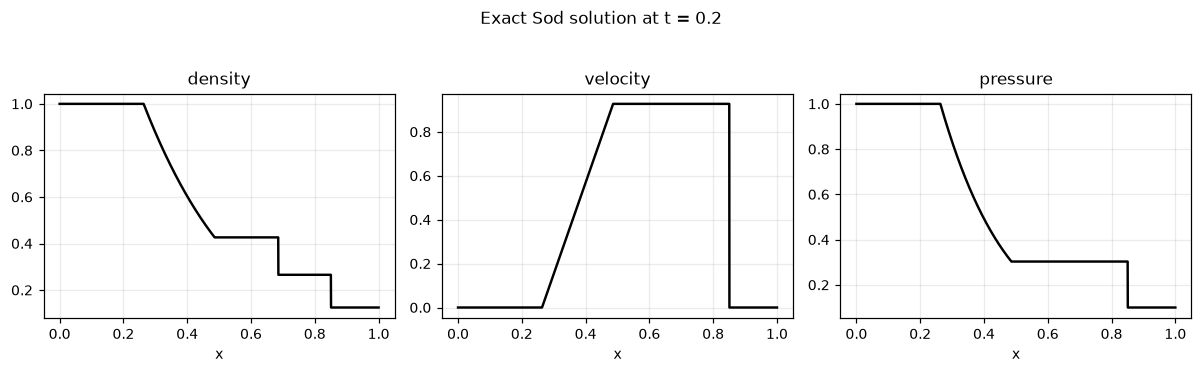

In [3]:
def exact_sample(xi, WL, WR, g=GAMMA):
    """Sample the exact solution at self-similar coordinate xi = (x - x0) / t."""
    rL, uL, pL = WL
    rR, uR, pR = WR
    aL, aR = np.sqrt(g * pL / rL), np.sqrt(g * pR / rR)
    ps, us = exact_star(WL, WR, g)
    gm, gp = g - 1.0, g + 1.0

    rho = np.empty_like(xi); u = np.empty_like(xi); p = np.empty_like(xi)

    for i, s in enumerate(np.atleast_1d(xi)):
        if s <= us:                                              # left of contact
            if ps > pL:                                          # left shock
                SL = uL - aL * np.sqrt(gp / (2 * g) * ps / pL + gm / (2 * g))
                if s <= SL:
                    rho[i], u[i], p[i] = rL, uL, pL
                else:
                    rho[i] = rL * (ps / pL + gm / gp) / (gm / gp * ps / pL + 1.0)
                    u[i], p[i] = us, ps
            else:                                                # left rarefaction
                a_star = aL * (ps / pL) ** (gm / (2 * g))
                if s <= uL - aL:
                    rho[i], u[i], p[i] = rL, uL, pL
                elif s >= us - a_star:
                    rho[i] = rL * (ps / pL) ** (1.0 / g)
                    u[i], p[i] = us, ps
                else:                                            # inside the fan
                    u[i] = 2.0 / gp * (aL + gm / 2.0 * uL + s)
                    a = 2.0 / gp * (aL + gm / 2.0 * (uL - s))
                    rho[i] = rL * (a / aL) ** (2.0 / gm)
                    p[i] = pL * (a / aL) ** (2.0 * g / gm)
        else:                                                    # right of contact
            if ps > pR:                                          # right shock
                SR = uR + aR * np.sqrt(gp / (2 * g) * ps / pR + gm / (2 * g))
                if s >= SR:
                    rho[i], u[i], p[i] = rR, uR, pR
                else:
                    rho[i] = rR * (ps / pR + gm / gp) / (gm / gp * ps / pR + 1.0)
                    u[i], p[i] = us, ps
            else:                                                # right rarefaction
                a_star = aR * (ps / pR) ** (gm / (2 * g))
                if s >= uR + aR:
                    rho[i], u[i], p[i] = rR, uR, pR
                elif s <= us + a_star:
                    rho[i] = rR * (ps / pR) ** (1.0 / g)
                    u[i], p[i] = us, ps
                else:
                    u[i] = 2.0 / gp * (-aR + gm / 2.0 * uR + s)
                    a = 2.0 / gp * (aR - gm / 2.0 * (uR - s))
                    rho[i] = rR * (a / aR) ** (2.0 / gm)
                    p[i] = pR * (a / aR) ** (2.0 * g / gm)
    return rho, u, p


x_fine = np.linspace(0, 1, 2000)
r_ex, u_ex, p_ex = exact_sample((x_fine - X0) / T_END, WL, WR)

fig, ax = plt.subplots(1, 3)
for a, y, lab in zip(ax, (r_ex, u_ex, p_ex), ("density", "velocity", "pressure")):
    a.plot(x_fine, y, "k", lw=1.6)
    a.set_xlabel("x"); a.set_title(lab)
fig.suptitle(f"Exact Sod solution at t = {T_END}", y=1.04)
plt.tight_layout(); plt.show()

Reading the density panel left to right: the **rarefaction fan** (smooth), a plateau, the
**contact** (a jump in density at constant pressure and velocity), another plateau, then the
**shock** (a jump in all three). The velocity and pressure panels have no contact jump at
all — which is exactly why the contact is the hardest of the three for a scheme to
resolve. Nothing in the pressure field marks it.

## 2. Three finite-volume schemes

Two independent choices, so three runs isolate them:

| Run | Riemann solver | Reconstruction |
|---|---|---|
| A | Rusanov (max wave speed only) | first order |
| B | Rusanov | MUSCL + minmod |
| C | HLLC (resolves the contact) | MUSCL + minmod |

A → B changes reconstruction order. B → C changes the Riemann solver.

In [4]:
def prim_to_cons(r, u, p, g=GAMMA):
    return np.array([r, r * u, p / (g - 1.0) + 0.5 * r * u * u])

def cons_to_prim(U, g=GAMMA):
    r = U[0]; u = U[1] / r
    p = (g - 1.0) * (U[2] - 0.5 * r * u * u)
    return r, u, p

def flux(U, g=GAMMA):
    r, u, p = cons_to_prim(U, g)
    return np.array([r * u, r * u * u + p, (U[2] + p) * u])


def rusanov(UL, UR, g=GAMMA):
    rL, uL, pL = cons_to_prim(UL, g); rR, uR, pR = cons_to_prim(UR, g)
    aL, aR = np.sqrt(g * pL / rL), np.sqrt(g * pR / rR)
    s = np.maximum(np.abs(uL) + aL, np.abs(uR) + aR)
    return 0.5 * (flux(UL, g) + flux(UR, g)) - 0.5 * s * (UR - UL)


def hllc(UL, UR, g=GAMMA):
    rL, uL, pL = cons_to_prim(UL, g); rR, uR, pR = cons_to_prim(UR, g)
    aL, aR = np.sqrt(g * pL / rL), np.sqrt(g * pR / rR)
    SL = np.minimum(uL - aL, uR - aR)
    SR = np.maximum(uL + aL, uR + aR)
    Ss = ((pR - pL + rL * uL * (SL - uL) - rR * uR * (SR - uR))
          / (rL * (SL - uL) - rR * (SR - uR)))

    def star(U, r, u, p, S):
        fac = r * (S - u) / (S - Ss)
        return np.array([fac,
                         fac * Ss,
                         fac * (U[2] / r + (Ss - u) * (Ss + p / (r * (S - u))))])

    FL, FR = flux(UL, g), flux(UR, g)
    F = np.where(SL >= 0, FL,
        np.where(Ss >= 0, FL + SL * (star(UL, rL, uL, pL, SL) - UL),
        np.where(SR >= 0, FR + SR * (star(UR, rR, uR, pR, SR) - UR), FR)))
    return F


def minmod(a, b):
    return np.where(a * b <= 0, 0.0, np.where(np.abs(a) < np.abs(b), a, b))

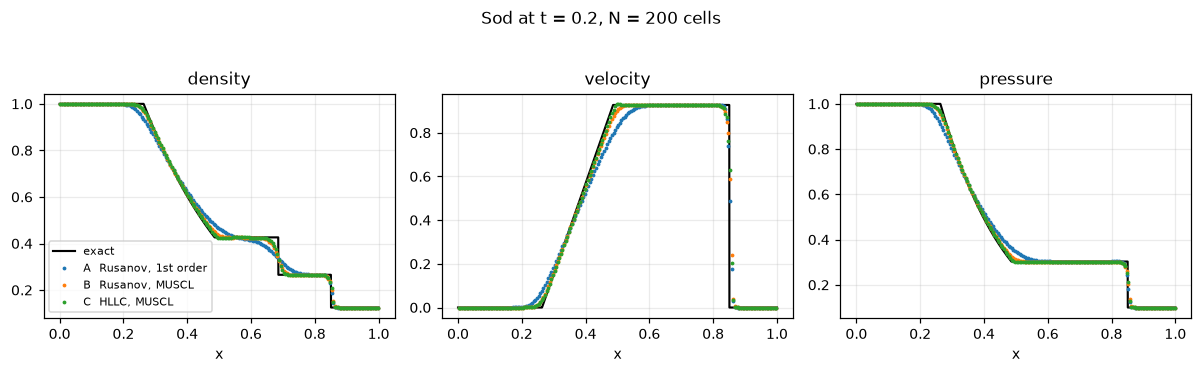

In [5]:
def rhs(U, dx, riemann, second_order, g=GAMMA):
    """Spatial operator: -dF/dx, with two mirrored ghost cells each side."""
    Ug = np.concatenate([U[:, :2][:, ::-1], U, U[:, -2:][:, ::-1]], axis=1)
    if second_order:
        d = np.diff(Ug, axis=1)
        slope = np.zeros_like(Ug)
        slope[:, 1:-1] = minmod(d[:, :-1], d[:, 1:])
        L = (Ug + 0.5 * slope)[:, 1:-2]          # left state at each face
        R = (Ug - 0.5 * slope)[:, 2:-1]          # right state
    else:
        L, R = Ug[:, 1:-2], Ug[:, 2:-1]
    F = riemann(L, R, g)
    return -(F[:, 1:] - F[:, :-1]) / dx


def solve(n, riemann, second_order, t_end=T_END, cfl=0.8, g=GAMMA):
    dx = 1.0 / n
    x = (np.arange(n) + 0.5) * dx
    r = np.where(x < X0, WL[0], WR[0])
    u = np.where(x < X0, WL[1], WR[1])
    p = np.where(x < X0, WL[2], WR[2])
    U = prim_to_cons(r, u, p, g)

    t = 0.0
    while t < t_end:
        r, u, p = cons_to_prim(U, g)
        a = np.sqrt(g * p / r)
        dt = min(cfl * dx / np.max(np.abs(u) + a), t_end - t)

        if second_order:
            # SSP-RK2 (Heun). Second-order reconstruction with forward Euler in time is
            # only first order overall — a mismatch that silently caps the observed rate.
            U1 = U + dt * rhs(U, dx, riemann, True, g)
            U = 0.5 * U + 0.5 * (U1 + dt * rhs(U1, dx, riemann, True, g))
        else:
            U = U + dt * rhs(U, dx, riemann, False, g)
        t += dt
    return x, U


runs = {
    "A  Rusanov, 1st order":  dict(riemann=rusanov, second_order=False),
    "B  Rusanov, MUSCL":      dict(riemann=rusanov, second_order=True),
    "C  HLLC, MUSCL":         dict(riemann=hllc,    second_order=True),
}

N = 200
fig, ax = plt.subplots(1, 3)
for a, comp, lab in zip(ax, range(3), ("density", "velocity", "pressure")):
    a.plot(x_fine, (r_ex, u_ex, p_ex)[comp], "k", lw=1.4, label="exact")
    for name, kw in runs.items():
        x, U = solve(N, **kw)
        a.plot(x, cons_to_prim(U)[comp], lw=0, marker=".", ms=3, label=name if comp == 0 else None)
    a.set_xlabel("x"); a.set_title(lab)
ax[0].legend(fontsize=7, loc="lower left")
fig.suptitle(f"Sod at t = {T_END}, N = {N} cells", y=1.04)
plt.tight_layout(); plt.show()

## 3. What the comparison shows

Zoom on the contact, which is where the three schemes differ most.

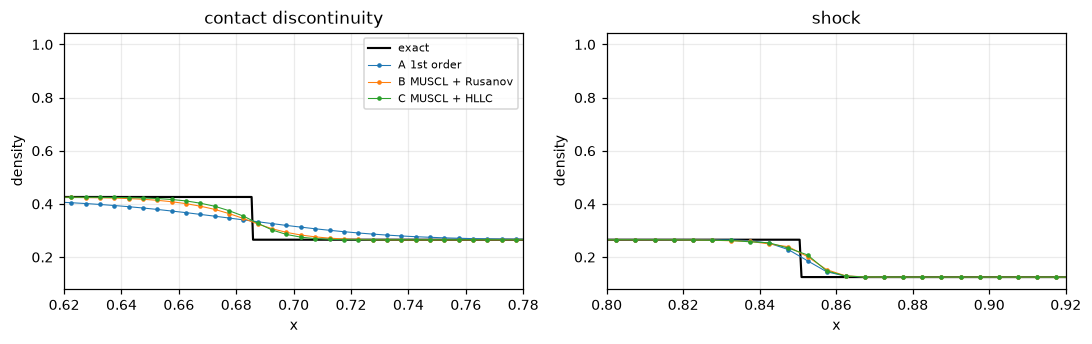

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))

x, U = solve(N, **runs["A  Rusanov, 1st order"]); rA = cons_to_prim(U)[0]
x, U = solve(N, **runs["B  Rusanov, MUSCL"]);     rB = cons_to_prim(U)[0]
x, U = solve(N, **runs["C  HLLC, MUSCL"]);        rC = cons_to_prim(U)[0]

for a, (lo, hi), title in zip(ax, [(0.62, 0.78), (0.80, 0.92)],
                              ["contact discontinuity", "shock"]):
    a.plot(x_fine, r_ex, "k", lw=1.4, label="exact")
    a.plot(x, rA, ".-", ms=4, lw=0.7, label="A 1st order")
    a.plot(x, rB, ".-", ms=4, lw=0.7, label="B MUSCL + Rusanov")
    a.plot(x, rC, ".-", ms=4, lw=0.7, label="C MUSCL + HLLC")
    a.set_xlim(lo, hi); a.set_title(title); a.set_xlabel("x"); a.set_ylabel("density")
ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

In [7]:
def contact_width(x, r, lo=0.60, hi=0.80):
    """Cells spanned by the 10-90% rise across the contact."""
    m = (x > lo) & (x < hi)
    xs, rs = x[m], r[m]
    r0, r1 = rs.max(), rs.min()
    thr_hi, thr_lo = r0 - 0.1 * (r0 - r1), r1 + 0.1 * (r0 - r1)
    inside = xs[(rs < thr_hi) & (rs > thr_lo)]
    return len(inside)

print(f"{'scheme':24s} {'L1 error (density)':>19} {'contact width (cells)':>23}")
for name, kw in runs.items():
    x, U = solve(N, **kw)
    r = cons_to_prim(U)[0]
    r_ref = exact_sample((x - X0) / T_END, WL, WR)[0]
    l1 = np.mean(np.abs(r - r_ref))
    print(f"{name:24s} {l1:19.5f} {contact_width(x, r):23d}")

scheme                    L1 error (density)   contact width (cells)
A  Rusanov, 1st order                0.01561                      21
B  Rusanov, MUSCL                    0.00627                      10
C  HLLC, MUSCL                       0.00479                       7


## 4. Convergence

Order of accuracy, measured rather than assumed. Note what it is *not*.

In [8]:
print(f"{'N':>6}" + "".join(f"{k.split()[0]:>12}" for k in runs))
errs = {k: [] for k in runs}
Ns = [100, 200, 400, 800]
for n in Ns:
    row = f"{n:6d}"
    for name, kw in runs.items():
        x, U = solve(n, **kw)
        r_ref = exact_sample((x - X0) / T_END, WL, WR)[0]
        e = np.mean(np.abs(cons_to_prim(U)[0] - r_ref))
        errs[name].append(e)
        row += f"{e:12.5f}"
    print(row)

print()
for name in runs:
    e = np.array(errs[name])
    p = np.log(e[:-1] / e[1:]) / np.log(2.0)
    print(f"{name:24s} observed order: " + "  ".join(f"{v:.2f}" for v in p))

     N           A           B           C
   100     0.02279     0.01182     0.00881
   200     0.01561     0.00627     0.00479


   400     0.01032     0.00346     0.00266


   800     0.00668     0.00195     0.00150

A  Rusanov, 1st order    observed order: 0.55  0.60  0.63
B  Rusanov, MUSCL        observed order: 0.92  0.86  0.83
C  HLLC, MUSCL           observed order: 0.88  0.85  0.82


**Nothing here converges at second order, and that is the point.** The
first-order scheme manages about 0.6; the two nominally second-order schemes reach about
0.85 — not 2.

This is Godunov's theorem in a measurement. A solution containing discontinuities cannot
reach the interior scheme's formal order in $L_1$, because the error is dominated by
the handful of cells smeared across each jump, and that smearing shrinks more slowly than
$\Delta x$. Report a scheme's order from a smooth manufactured solution; report its
accuracy from the problem you actually care about. They are different claims.

The second-order schemes still win decisively — at $N=800$ the error is over four times
smaller, and the contact is resolved in half the cells. What improves is the constant, not
the exponent.

Three takeaways that transfer:

1. **Reconstruction order buys sharpness, not convergence rate**, on discontinuous
   problems. Quote order from a smooth test case and accuracy from the real one.
2. **The Riemann solver matters most at the contact.** Rusanov uses only the maximum wave
   speed, so it has no mechanism to resolve a wave moving at the fluid velocity; HLLC
   restores it. The shock is nearly identical between them.
3. **The contact is the sensitive diagnostic.** It carries no pressure signature, so
   nothing in the momentum or energy balance pushes a scheme to keep it sharp.

## Connections

- [Compressible flow](../fluids/compressible.md) — Riemann solvers, limiters, and the failure modes
- [Finite volume](../fluids/cfd/finite-volume.md) — reconstruction and numerical diffusion
- [Numerical methods](../foundations/numerical-methods.md) — Godunov's theorem, observed order
- [Verification and validation](../foundations/verification-validation.md) — measuring order properly